## ThinkDSP

This notebook contains code examples from Chapter 3: Non-periodic signals

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [ ]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

### Chirp

Make a linear chirp from A3 to A5.

In [ ]:
from thinkdsp import Chirp

signal = Chirp(start=220, end=880)
wave1 = signal.make_wave(duration=2)
wave1.make_audio()

Here's what the waveform looks like near the beginning.

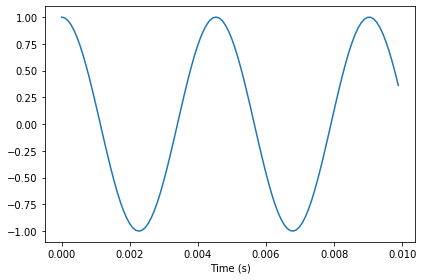

In [ ]:
wave1.segment(start=0, duration=0.01).plot()
decorate(xlabel='Time (s)')

And near the end.

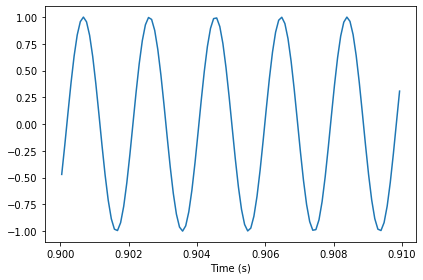

In [ ]:
wave1.segment(start=0.9, duration=0.01).plot()
decorate(xlabel='Time (s)')

Here's an exponential chirp with the same frequency range and duration.

In [ ]:
from thinkdsp import ExpoChirp

signal = ExpoChirp(start=220, end=880)
wave2 = signal.make_wave(duration=2)
wave2.make_audio()

## Leakage

Spectral leakage is when some of the energy at one frequency appears at another frequency (usually nearby).

Let's look at the effect of leakage on a sine signal (which only contains one frequency component).

In [ ]:
from thinkdsp import SinSignal

signal = SinSignal(freq=440)

If the duration is an integer multiple of the period, the beginning and end of the segment line up, and we get minimal leakage.

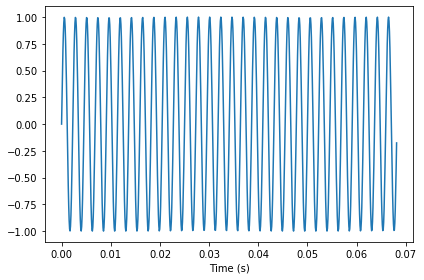

In [ ]:
duration = signal.period * 30
wave = signal.make_wave(duration)
wave.plot()
decorate(xlabel='Time (s)')

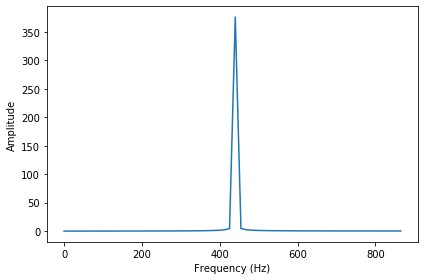

In [ ]:
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

If the duration is not a multiple of a period, the leakage is pretty bad.

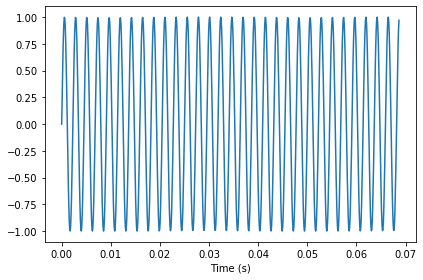

In [ ]:
duration = signal.period * 30.25
wave = signal.make_wave(duration)
wave.plot()
decorate(xlabel='Time (s)')

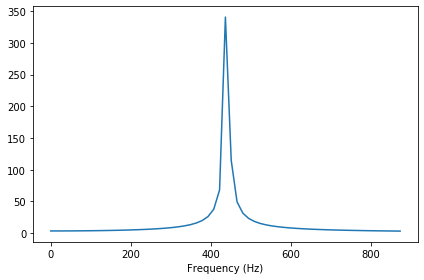

In [ ]:
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

Windowing helps (but notice that it reduces the total energy).

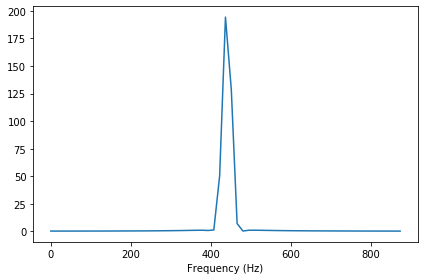

In [ ]:
wave.hamming()
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

## Spectrogram

If you blindly compute the DFT of a non-periodic segment, you get "motion blur".

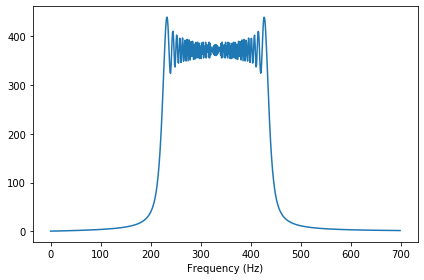

In [ ]:
signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1)
spectrum = wave.make_spectrum()
spectrum.plot(high=700)
decorate(xlabel='Frequency (Hz)')

A spectrogram is a visualization of a short-time DFT that lets you see how the spectrum varies over time.

In [ ]:
def plot_spectrogram(wave, seg_length):
    """
    """
    spectrogram = wave.make_spectrogram(seg_length)
    print('Time resolution (s)', spectrogram.time_res)
    print('Frequency resolution (Hz)', spectrogram.freq_res)
    spectrogram.plot(high=700)
    decorate(xlabel='Time(s)', ylabel='Frequency (Hz)')

Time resolution (s) 0.046439909297052155
Frequency resolution (Hz) 21.533203125


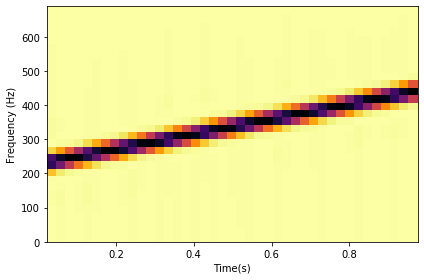

In [ ]:
signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1, framerate=11025)
plot_spectrogram(wave, 512)

If you increase the segment length, you get better frequency resolution, worse time resolution.

Time resolution (s) 0.09287981859410431
Frequency resolution (Hz) 10.7666015625


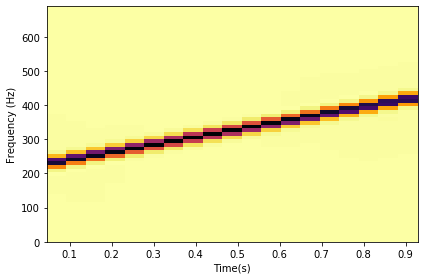

In [ ]:
plot_spectrogram(wave, 1024)

If you decrease the segment length, you get better time resolution, worse frequency resolution.

Time resolution (s) 0.023219954648526078
Frequency resolution (Hz) 43.06640625


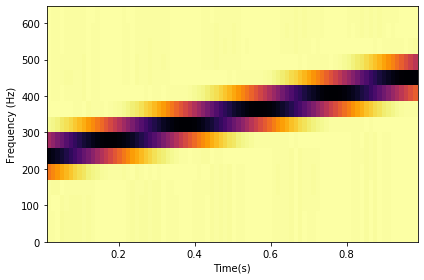

In [ ]:
plot_spectrogram(wave, 256)

Time resolution (s) 0.011609977324263039
Frequency resolution (Hz) 86.1328125


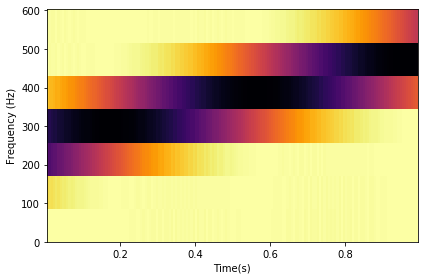

In [ ]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.IntSlider(min=128, max=4096, value=100, step=128)
interact(plot_spectrogram, wave=fixed(wave), seg_length=slider);

## Spectrum of a chirp

The following interaction lets you customize the Eye of Sauron as you vary the start and end frequency of the chirp.

In [ ]:
def eye_of_sauron(start, end):
    """Plots the spectrum of a chirp.

    start: initial frequency
    end: final frequency
    """
    signal =  Chirp(start=start, end=end)
    wave = signal.make_wave(duration=0.5)
    spectrum = wave.make_spectrum()

    spectrum.plot(high=1200)
    decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

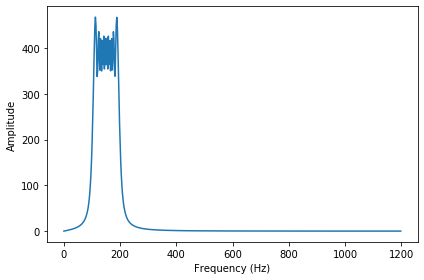

In [ ]:
slider1 = widgets.FloatSlider(min=100, max=1000, value=100, step=50)
slider2 = widgets.FloatSlider(min=100, max=1000, value=200, step=50)
interact(eye_of_sauron, start=slider1, end=slider2);

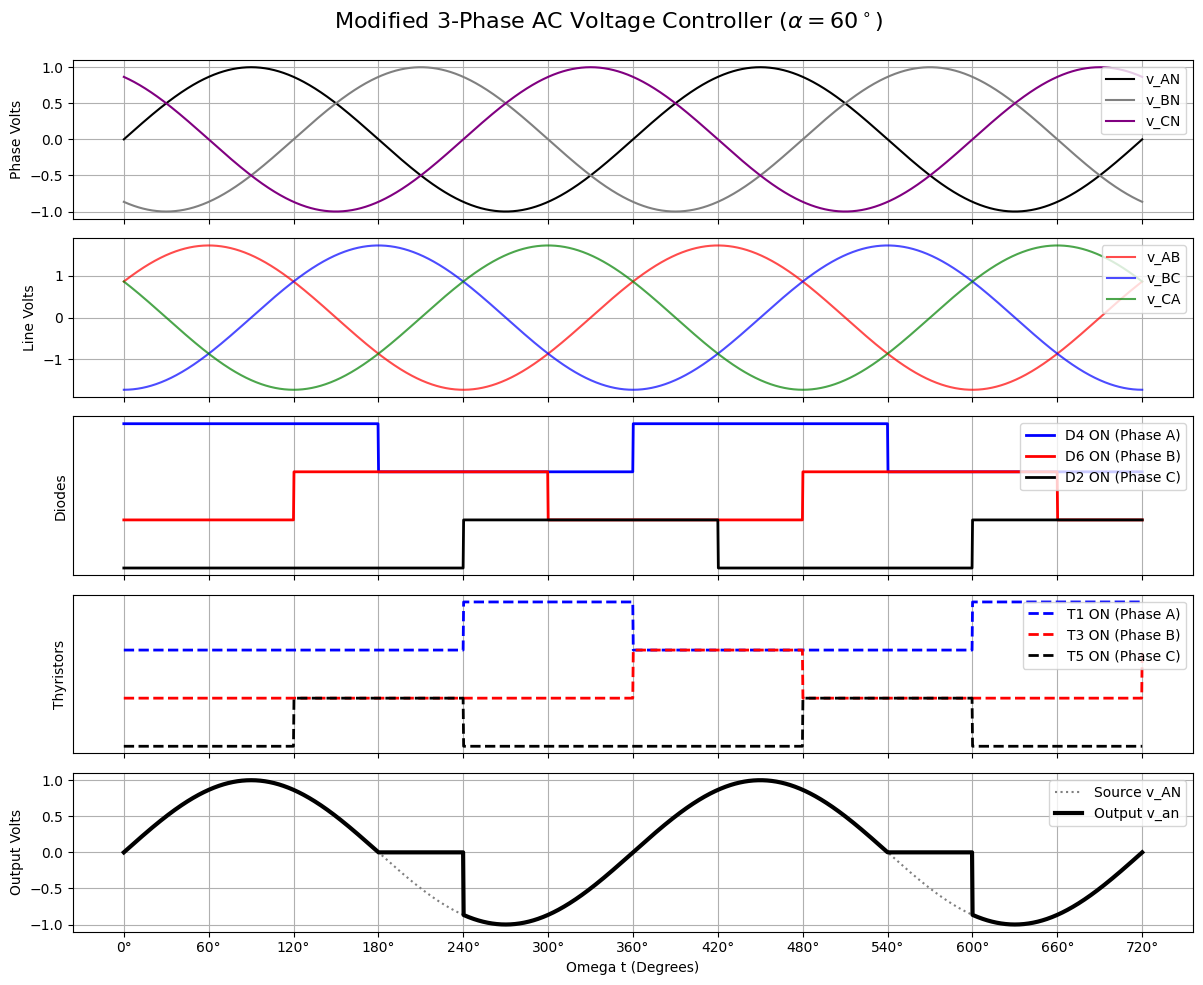

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup Time Axis and Parameters ---
# wt from 0 to 720 degrees (4*pi) for two full cycles
wt_deg = np.linspace(0, 720, 2000)
wt_rad = np.radians(wt_deg)
alpha = 60  # Firing angle in degrees

# --- 2. Calculate Voltages ---
# Phase Voltages
van = np.sin(wt_rad)
vbn = np.sin(wt_rad - np.radians(120))
vcn = np.sin(wt_rad + np.radians(120))

# Line Voltages (scaled down slightly for plotting visibility if needed, but keeping actual relation)
vab = van - vbn
vbc = vbn - vcn
vca = vcn - van

# --- 3. Define Logic Blocks (Conduction States) ---
def square_wave(starts, ends, length):
    wave = np.zeros(length)
    for s, e in zip(starts, ends):
        wave[(wt_deg >= s) & (wt_deg <= e)] = 1
    return wave

# Uncontrolled Forward Diodes (D4=Phase A, D6=Phase B, D2=Phase C)
# D4 conducts 0-180, 360-540
D4 = square_wave([0, 360], [180, 540], len(wt_deg))
# D6 conducts 120-300, 480-660
D6 = square_wave([120, 480], [300, 660], len(wt_deg))
# D2 conducts 240-420, 600-780
D2 = square_wave([240, 600], [420, 780], len(wt_deg))

# Controlled Reverse Thyristors (T1=Phase A, T3=Phase B, T5=Phase C) with alpha delay
# T1 conducts negative half of A (180 to 360) starting at 180+alpha
T1 = square_wave([180+alpha, 540+alpha], [360, 720], len(wt_deg))
# T3 conducts negative half of B (300 to 480) starting at 300+alpha
T3 = square_wave([300+alpha, 660+alpha], [480, 840], len(wt_deg))
# T5 conducts negative half of C (60 to 240) starting at 60+alpha
T5 = square_wave([60+alpha, 420+alpha], [240, 600], len(wt_deg))

# --- 4. Calculate Final Output Voltage (Phase A: van_out) ---
van_out = np.zeros_like(wt_deg)
for i, deg in enumerate(wt_deg):
    # Positive half cycle: D4 is ON, exactly follows van
    if D4[i] == 1:
        van_out[i] = van[i]
    # Negative half cycle: T1 is ON, follows van after alpha delay
    elif T1[i] == 1:
        van_out[i] = van[i]
    # Otherwise it is 0 (the gap)
    else:
        van_out[i] = 0

# --- 5. Plotting ---
fig, axs = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
fig.suptitle(r'Modified 3-Phase AC Voltage Controller ($\alpha = 60^\circ$)', fontsize=16)

# X-axis ticks every 60 degrees for easy reading
xticks = np.arange(0, 721, 60)
xticklabels = [f"{x}°" for x in xticks]

# Plot 1: Phase Voltages
axs[0].plot(wt_deg, van, label='v_AN', color='black')
axs[0].plot(wt_deg, vbn, label='v_BN', color='gray')
axs[0].plot(wt_deg, vcn, label='v_CN', color='purple')
axs[0].set_ylabel('Phase Volts')
axs[0].legend(loc='upper right')
axs[0].grid(True)

# Plot 2: Line Voltages
axs[1].plot(wt_deg, vab, label='v_AB', color='red', alpha=0.7)
axs[1].plot(wt_deg, vbc, label='v_BC', color='blue', alpha=0.7)
axs[1].plot(wt_deg, vca, label='v_CA', color='green', alpha=0.7)
axs[1].set_ylabel('Line Volts')
axs[1].legend(loc='upper right')
axs[1].grid(True)

# Plot 3: Forward Diodes (Offset vertically so they don't overlap)
axs[2].plot(wt_deg, D4 + 2, label='D4 ON (Phase A)', color='blue', linewidth=2)
axs[2].plot(wt_deg, D6 + 1, label='D6 ON (Phase B)', color='red', linewidth=2)
axs[2].plot(wt_deg, D2, label='D2 ON (Phase C)', color='black', linewidth=2)
axs[2].set_ylabel('Diodes')
axs[2].set_yticks([]) # Hide Y values
axs[2].legend(loc='upper right')
axs[2].grid(True)

# Plot 4: Reverse Thyristors (Offset vertically)
axs[3].plot(wt_deg, T1 + 2, label='T1 ON (Phase A)', color='blue', linewidth=2, linestyle='--')
axs[3].plot(wt_deg, T3 + 1, label='T3 ON (Phase B)', color='red', linewidth=2, linestyle='--')
axs[3].plot(wt_deg, T5, label='T5 ON (Phase C)', color='black', linewidth=2, linestyle='--')
axs[3].set_ylabel('Thyristors')
axs[3].set_yticks([])
axs[3].legend(loc='upper right')
axs[3].grid(True)

# Plot 5: Output Voltage (v_an)
axs[4].plot(wt_deg, van, color='gray', linestyle=':', label='Source v_AN')
axs[4].plot(wt_deg, van_out, color='black', linewidth=3, label='Output v_an')
axs[4].set_ylabel('Output Volts')
axs[4].set_xlabel('Omega t (Degrees)')
axs[4].set_xticks(xticks)
axs[4].set_xticklabels(xticklabels)
axs[4].legend(loc='upper right')
axs[4].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()